In [ ]:
! pip install langchain langchain-huggingface langchain-community langgraph python-dotenv faiss-cpu pypdf

In [32]:
from typing import Annotated

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import AIMessage, AnyMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [34]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [35]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [36]:
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

def chatNode(state: ChatState):
  decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
  if decision["approved"] == 'no':
    return {"messages": [AIMessage(content="Not approved.")]}
  else:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

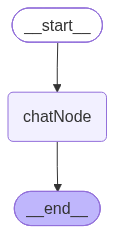

In [37]:
graph = StateGraph(ChatState)
graph.add_node("chatNode", chatNode)

graph.add_edge(START, "chatNode")
graph.add_edge("chatNode", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = graph.compile(checkpointer=checkpointer)
app

In [38]:
config = {"configurable": {"thread_id": "1111"}}
query = {"messages": [("user", "Explain Gradient Descent")]}

result = app.invoke(query, config=config)
result

{'messages': [HumanMessage(content='Explain Gradient Descent', additional_kwargs={}, response_metadata={}, id='648bec56-c700-458a-a07b-79cc974ec061')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain Gradient Descent', 'instruction': 'Approve this question? yes/no'}, id='b98a6d25645182611730a57304a4a4c1')]}

In [39]:
approvalMessage = result['__interrupt__'][0].value
approvalMessage

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain Gradient Descent',
 'instruction': 'Approve this question? yes/no'}

In [40]:
user_input = input(f"\nBackend message - {approvalMessage} \n Approve this question? (y/n): ")


Backend message - {'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain Gradient Descent', 'instruction': 'Approve this question? yes/no'} 
 Approve this question? (y/n): no


In [41]:
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)
final_result

{'messages': [HumanMessage(content='Explain Gradient Descent', additional_kwargs={}, response_metadata={}, id='648bec56-c700-458a-a07b-79cc974ec061'),
  AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='220ce897-41f3-4cf2-9748-f54a9d86a8cb', tool_calls=[], invalid_tool_calls=[])]}

### HITL WITH TOOLS

In [43]:
from langgraph.graph import StateGraph, START
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.types import interrupt, Command
from dotenv import load_dotenv

import requests

In [45]:
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
    using Alpha Vantage with API key in the URL.
    """
    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=RH0QU3928RW8QSWC"
    )
    r = requests.get(url)
    return r.json()


@tool
def purchase_stock(symbol: str, quantity: int) -> dict:
    """
    Simulate purchasing a given quantity of a stock symbol.

    HUMAN-IN-THE-LOOP:
    Before confirming the purchase, this tool will interrupt
    and wait for a human decision ("yes" / anything else).
    """
    # This pauses the graph and returns control to the caller
    decision = interrupt(f"Approve buying {quantity} shares of {symbol}? (yes/no)")

    if isinstance(decision, str) and decision.lower() == "yes":
        return {
            "status": "success",
            "message": f"Purchase order placed for {quantity} shares of {symbol}.",
            "symbol": symbol,
            "quantity": quantity,
        }

    else:
        return {
            "status": "cancelled",
            "message": f"Purchase of {quantity} shares of {symbol} was declined by human.",
            "symbol": symbol,
            "quantity": quantity,
        }


tools = [get_stock_price, purchase_stock]
llm_with_tools = model.bind_tools(tools)

In [46]:
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [47]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

memory = MemorySaver()

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

chatbot = graph.compile(checkpointer=memory)

if __name__ == "__main__":

    # Use a fixed thread_id so the conversation is persisted in memory
    thread_id = "demo-thread"

    while True:
        user_input = input("You: ")
        if user_input.lower().strip() in {"exit", "quit"}:
            print("Goodbye!")
            break

        # Build initial state for this turn
        state = {"messages": [HumanMessage(content=user_input)]}

        # Run the graph (may hit an interrupt)
        result = chatbot.invoke(
            state,
            config={"configurable": {"thread_id": thread_id}},
        )

        # Check for HITL interrupt from purchase_stock
        interrupts = result.get("__interrupt__", [])

        if interrupts:
            # Our interrupt payload is the string we passed to interrupt(...)
            prompt_to_human = interrupts[0].value
            print(f"HITL: {prompt_to_human}")
            decision = input("Your decision: ").strip().lower()

            # Resume graph with the human decision ("yes" / "no" / whatever)
            result = chatbot.invoke(
                Command(resume=decision),
                config={"configurable": {"thread_id": thread_id}},
            )

        # Get the latest message from the assistant
        messages = result["messages"]
        last_msg = messages[-1]
        print(f"Bot: {last_msg.content}\n")

You: Hi
Bot: Hello! How can I assist you today?

You: What is Current Stock price of AAPL
Bot: The current stock price of AAPL (Apple Inc.) is **$333.08**.  

Additional details:
- **Previous Close**: $332.27  
- **Change**: +$0.81 (+0.24%)  
- **Day's High**: $335.50  
- **Day's Low**: $331.34  
- **Volume**: 39,269,147  

Let me know if you'd like help with anything else! 😊

You: Buy me 100 Shares of AAPL
HITL: Approve buying 100 shares of AAPL? (yes/no)
Your decision: yes
Bot: Your purchase order has been successfully placed! 🎉  

You've bought **100 shares of AAPL**.  

Let me know if you'd like to explore other investments or need assistance with anything else! 💼📊

You: bye
Bot: Goodbye! Feel free to reach out anytime. Have a great day! 😊✨

You: no
Bot: I'm here if you need any help! Let me know how I can assist you today. 😊

You: exit
Goodbye!
